#  SAR Ship Detection — SSDD Dataset
### Lightweight YOLOv8n Model | COCO-format Annotations



In [2]:
import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU detected — go to Runtime → Change runtime type → T4 GPU")

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# ─────────────────────────────────────────────────────────────────────────────
# 🔧 CONFIGURE THIS: path to your SSDD COCO-format folder inside Google Drive
# Expected structure:
#   SSDD_COCO/
#     train/          ← images
#     test/           ← images
#     test_inshore/   ← images
#     test_offshore/  ← images
#     annotations/
#       instances_train.json
#       instances_test.json
#       instances_test_inshore.json
#       instances_test_offshore.json
# ─────────────────────────────────────────────────────────────────────────────
DRIVE_DATASET_PATH = "/content/drive/MyDrive/dataset/coco_style"   # ← CHANGE THIS

import os
assert os.path.isdir(DRIVE_DATASET_PATH), (
    f"❌ Folder not found: {DRIVE_DATASET_PATH}\n"
    "   Please update DRIVE_DATASET_PATH above."
)
print("✅ Dataset folder found:", DRIVE_DATASET_PATH)

# List top-level contents
for item in sorted(os.listdir(DRIVE_DATASET_PATH)):
    full = os.path.join(DRIVE_DATASET_PATH, item)
    if os.path.isdir(full):
        count = len(os.listdir(full))
        print(f"   📁 {item}/  ({count} files)")
    else:
        print(f"   📄 {item}")

Mounted at /content/drive
✅ Dataset folder found: /content/drive/MyDrive/dataset/coco_style
   📄 1.jpg
   📁 annotations/  (4 files)
   📁 images/  (5 files)
   📄 plot_polylines.py
   📄 visualization_coco.py


In [3]:
!pip install -q ultralytics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 41.6 MB/s eta 0:00:00


## 2. Dataset

In [4]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# ── Annotation file discovery ───────────────────────────────────────────────
ann_dir = os.path.join(DRIVE_DATASET_PATH, "annotations")

# Try common naming conventions
SPLITS = {
    "train":          ["train.json", "train.json", "train_coco.json"],
    "test":           ["test.json",  "test.json",  "test_coco.json"],
    "test_inshore":   ["test_inshore.json",  "test_inshore.json"],
    "test_offshore":  ["test_offshore.json", "test_offshore.json"],
}

ann_files = {}
for split, candidates in SPLITS.items():
    for c in candidates:
        p = os.path.join(ann_dir, c)
        if os.path.isfile(p):
            ann_files[split] = p
            break

print("Annotation files found:")
for split, path in ann_files.items():
    with open(path) as f:
        d = json.load(f)
    n_img = len(d.get("images", []))
    n_ann = len(d.get("annotations", []))
    print(f"  [{split:>15}]  images={n_img:4d}  annotations={n_ann:5d}  → {os.path.basename(path)}")

# Category check
with open(ann_files['train']) as f:
    train_data = json.load(f)
print("\nCategories:", train_data['categories'])

Annotation files found:
  [          train]  images= 928  annotations= 2041  → train.json
  [           test]  images= 232  annotations=  546  → test.json
  [   test_inshore]  images=  46  annotations=  172  → test_inshore.json
  [  test_offshore]  images= 186  annotations=  374  → test_offshore.json

Categories: [{'supercategory': 'none', 'id': 0, 'name': 'ship'}]


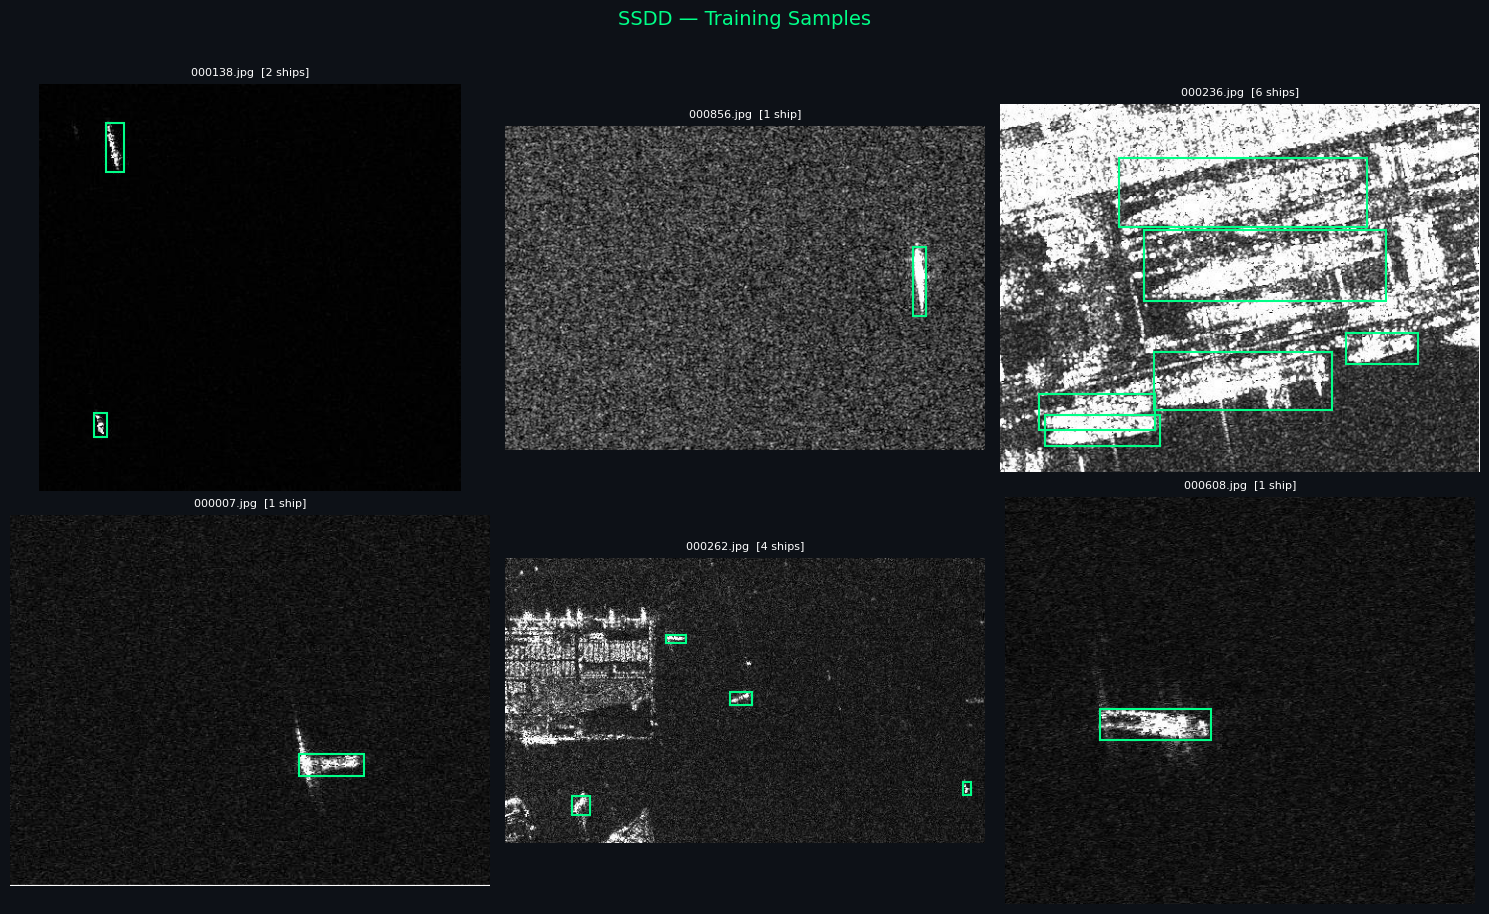

Total training images : 928
Total annotations     : 2041


In [6]:
# ── Visualise 6 random training samples ─────────────────────────────────────
import random

img_dir_train = os.path.join(DRIVE_DATASET_PATH, "images/train")

# Build id → filename map
id2file = {img['id']: img['file_name'] for img in train_data['images']}

# Group annotations by image id
from collections import defaultdict
ann_by_img = defaultdict(list)
for ann in train_data['annotations']:
    ann_by_img[ann['image_id']].append(ann)

sample_ids = random.sample(list(id2file.keys()), min(6, len(id2file)))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
fig.patch.set_facecolor('#0d1117')

for ax, img_id in zip(axes, sample_ids):
    fname = id2file[img_id]
    # Handle nested paths in file_name
    img_path = os.path.join(DRIVE_DATASET_PATH, fname) if '/' in fname else os.path.join(img_dir_train, fname)
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_facecolor('#0d1117')

    for ann in ann_by_img[img_id]:
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h,
                                  linewidth=1.5, edgecolor='#00ff88', facecolor='none')
        ax.add_patch(rect)

    n = len(ann_by_img[img_id])
    ax.set_title(f"{os.path.basename(fname)}  [{n} ship{'s' if n!=1 else ''}]",
                 color='white', fontsize=8)
    ax.axis('off')

plt.suptitle("SSDD — Training Samples", color='#00ff88', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print(f"Total training images : {len(id2file)}")
print(f"Total annotations     : {len(train_data['annotations'])}")

## 4. Convert COCO → YOLO Format

In [26]:
import shutil, os, json
from collections import defaultdict

YOLO_ROOT = "/content/drive/MyDrive/ssdd_yolo"
IMG_ROOT  = "/content/drive/MyDrive/dataset/coco_style/images"

# Wipe old conversion
if os.path.exists(YOLO_ROOT):
    shutil.rmtree(YOLO_ROOT)
    print("Cleared old YOLO folder")

def coco_to_yolo(ann_file, yolo_split_dir, split_name):
    with open(ann_file) as f:
        data = json.load(f)

    img_out = os.path.join(yolo_split_dir, "images")
    lbl_out = os.path.join(yolo_split_dir, "labels")
    os.makedirs(img_out, exist_ok=True)
    os.makedirs(lbl_out, exist_ok=True)

    # Auto-detect if category_id is 0-based or 1-based
    all_cat_ids = [ann['category_id'] for ann in data['annotations']]
    offset = 1 if min(all_cat_ids) >= 1 else 0  # subtract 1 only if 1-based
    print(f"  [{split_name}] category_id range: {min(all_cat_ids)}-{max(all_cat_ids)}, offset={offset}")

    id2info = {img['id']: img for img in data['images']}
    ann_map = defaultdict(list)
    for ann in data['annotations']:
        ann_map[ann['image_id']].append(ann)

    copied = skipped = 0
    for img_id, img_info in id2info.items():
        fname = img_info['file_name']
        W, H  = img_info['width'], img_info['height']
        stem  = os.path.splitext(os.path.basename(fname))[0]
        base  = os.path.basename(fname)

        candidates = [
            os.path.join(IMG_ROOT, split_name, base),
            os.path.join(IMG_ROOT, base),
            os.path.join("/content/drive/MyDrive/dataset/coco_style", split_name, base),
        ]
        src = next((c for c in candidates if os.path.isfile(c)), None)

        if src is None:
            skipped += 1
            continue

        shutil.copy2(src, os.path.join(img_out, base))

        lines = []
        for ann in ann_map[img_id]:
            x, y, w, h = ann['bbox']
            # Clamp to valid range
            x, y = max(0, x), max(0, y)
            w = min(w, W - x)
            h = min(h, H - y)
            if w <= 0 or h <= 0:
                continue
            cx = (x + w/2) / W
            cy = (y + h/2) / H
            nw, nh = w / W, h / H
            cat = ann['category_id'] - offset
            lines.append(f"{cat} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        with open(os.path.join(lbl_out, stem + ".txt"), 'w') as lf:
            lf.write("\n".join(lines))
        copied += 1

    print(f"  [{split_name:>15}]  ✅ {copied} converted  ⚠️  {skipped} skipped")

print("Converting COCO → YOLO ...")
split_dirs = {}
for split, ann_path in ann_files.items():
    out_dir = os.path.join(YOLO_ROOT, split)
    split_dirs[split] = out_dir
    coco_to_yolo(ann_path, out_dir, split)
print("Done.")

Converting COCO → YOLO ...
  [train] category_id range: 0-0, offset=0
  [          train]  ✅ 928 converted  ⚠️  0 skipped
  [test] category_id range: 0-0, offset=0
  [           test]  ✅ 232 converted  ⚠️  0 skipped
  [test_inshore] category_id range: 0-0, offset=0
  [   test_inshore]  ✅ 46 converted  ⚠️  0 skipped
  [test_offshore] category_id range: 0-0, offset=0
  [  test_offshore]  ✅ 186 converted  ⚠️  0 skipped
Done.


## 5. Write YAML Config for YOLOv8

In [27]:
import yaml

# Category names from annotation file
cat_names = [c['name'] for c in sorted(train_data['categories'], key=lambda x: x['id'])]

yaml_cfg = {
    'path':  YOLO_ROOT,
    'train': 'train/images',
    'val':   'test/images',        # use test as validation
    'test':  'test/images',
    'nc':    len(cat_names),
    'names': cat_names,
}

YAML_PATH = "/content/ssdd.yaml"
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False)

print("YAML written to:", YAML_PATH)
print(yaml.dump(yaml_cfg))

YAML written to: /content/ssdd.yaml
names:
- ship
nc: 1
path: /content/drive/MyDrive/ssdd_yolo
test: test/images
train: train/images
val: test/images



## 6. Train YOLOv8n

In [28]:
from ultralytics import YOLO
import torch

model = YOLO("yolov8n.pt")
model.train(
    data     = YAML_PATH,
    epochs   = 50,
    imgsz    = 640,
    batch    = 16,
    lr0      = 0.01,
    mosaic   = 1.0,
    flipud   = 0.5,
    fliplr   = 0.5,
    degrees  = 10,
    hsv_s    = 0.0,
    hsv_h    = 0.0,
    name     = "ssdd_yolov8n",
    project  = "/content/runs",
    exist_ok = True,
    patience = 20,
    device   = 0 if torch.cuda.is_available() else 'cpu',
)
BEST_WEIGHTS = "/content/runs/ssdd_yolov8n/weights/best.pt"
print("✅ Done:", BEST_WEIGHTS)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ssdd.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ssdd_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=

## 7. Training Curves

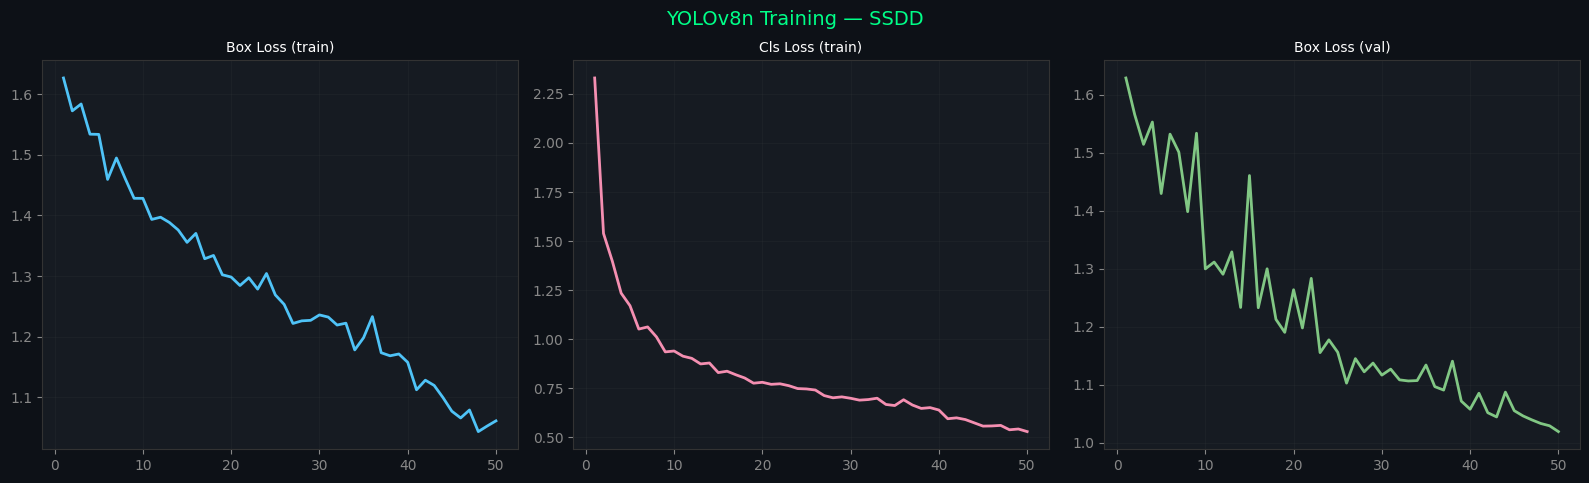

In [29]:
import pandas as pd

csv_path = "/content/runs/ssdd_yolov8n/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("YOLOv8n Training — SSDD", color='#00ff88', fontsize=14)

METRICS = [
    ('train/box_loss',  'Box Loss (train)',   '#4fc3f7'),
    ('train/cls_loss',  'Cls Loss (train)',   '#f48fb1'),
    ('val/box_loss',    'Box Loss (val)',      '#81c784'),
    ('metrics/mAP50',  'mAP@50',             '#ffb74d'),
    ('metrics/mAP50-95','mAP@50-95',          '#ce93d8'),
    ('metrics/precision','Precision',          '#80cbc4'),
]

for ax, (col, title, color) in zip(axes.flatten(), METRICS):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color=color, linewidth=2)
        ax.set_title(title, color='white', fontsize=10)
        ax.set_facecolor('#161b22')
        ax.tick_params(colors='#888')
        ax.spines[:].set_color('#333')
        ax.grid(alpha=0.15, color='#444')
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

## 8. Evaluate on All Test Splits

In [30]:
trained_model = YOLO(BEST_WEIGHTS)

test_splits = [s for s in ['test', 'test_inshore', 'test_offshore'] if s in split_dirs]

eval_results = {}
for split in test_splits:
    # Temporarily update yaml for this split
    yaml_cfg['val'] = f"{split}/images"
    with open(YAML_PATH, 'w') as f:
        yaml.dump(yaml_cfg, f)

    r = trained_model.val(
        data=YAML_PATH,
        split='val',
        imgsz=640,
        conf=0.25,
        iou=0.5,
        verbose=False,
    )
    eval_results[split] = r
    print(f"[{split:>15}]  mAP@50={r.box.map50:.4f}  mAP@50-95={r.box.map:.4f}  "
          f"P={r.box.mp:.4f}  R={r.box.mr:.4f}")

# Restore yaml
yaml_cfg['val'] = 'test/images'
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_cfg, f)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.2 ms, read: 23.7±7.6 MB/s, size: 48.4 KB)
val: Scanning /content/drive/MyDrive/ssdd_yolo/test/labels.cache... 232 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 232/232 64.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 2.9it/s 5.2s
                   all        232        546      0.958      0.941       0.97      0.727
Speed: 3.5ms preprocess, 8.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
[           test]  mAP@50=0.9700  mAP@50-95=0.7274  P=0.9576  R=0.9414
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.3 ms, read: 39.7±25.9 MB/s, size: 83.8 KB)
val: Scanning /content/drive/MyDriv

In [31]:
# ── Summary table ────────────────────────────────────────────────────────────
print("\n" + "═"*62)
print(f"{'Split':<18} {'mAP@50':>8} {'mAP@50-95':>10} {'Precision':>10} {'Recall':>8}")
print("─"*62)
for split, r in eval_results.items():
    print(f"{split:<18} {r.box.map50:>8.4f} {r.box.map:>10.4f} {r.box.mp:>10.4f} {r.box.mr:>8.4f}")
print("═"*62)


══════════════════════════════════════════════════════════════
Split                mAP@50  mAP@50-95  Precision   Recall
──────────────────────────────────────────────────────────────
test                 0.9700     0.7274     0.9576   0.9414
test_inshore         0.9191     0.6736     0.9013   0.8491
test_offshore        0.9895     0.7522     0.9787   0.9806
══════════════════════════════════════════════════════════════


## 9. Visualise Detections

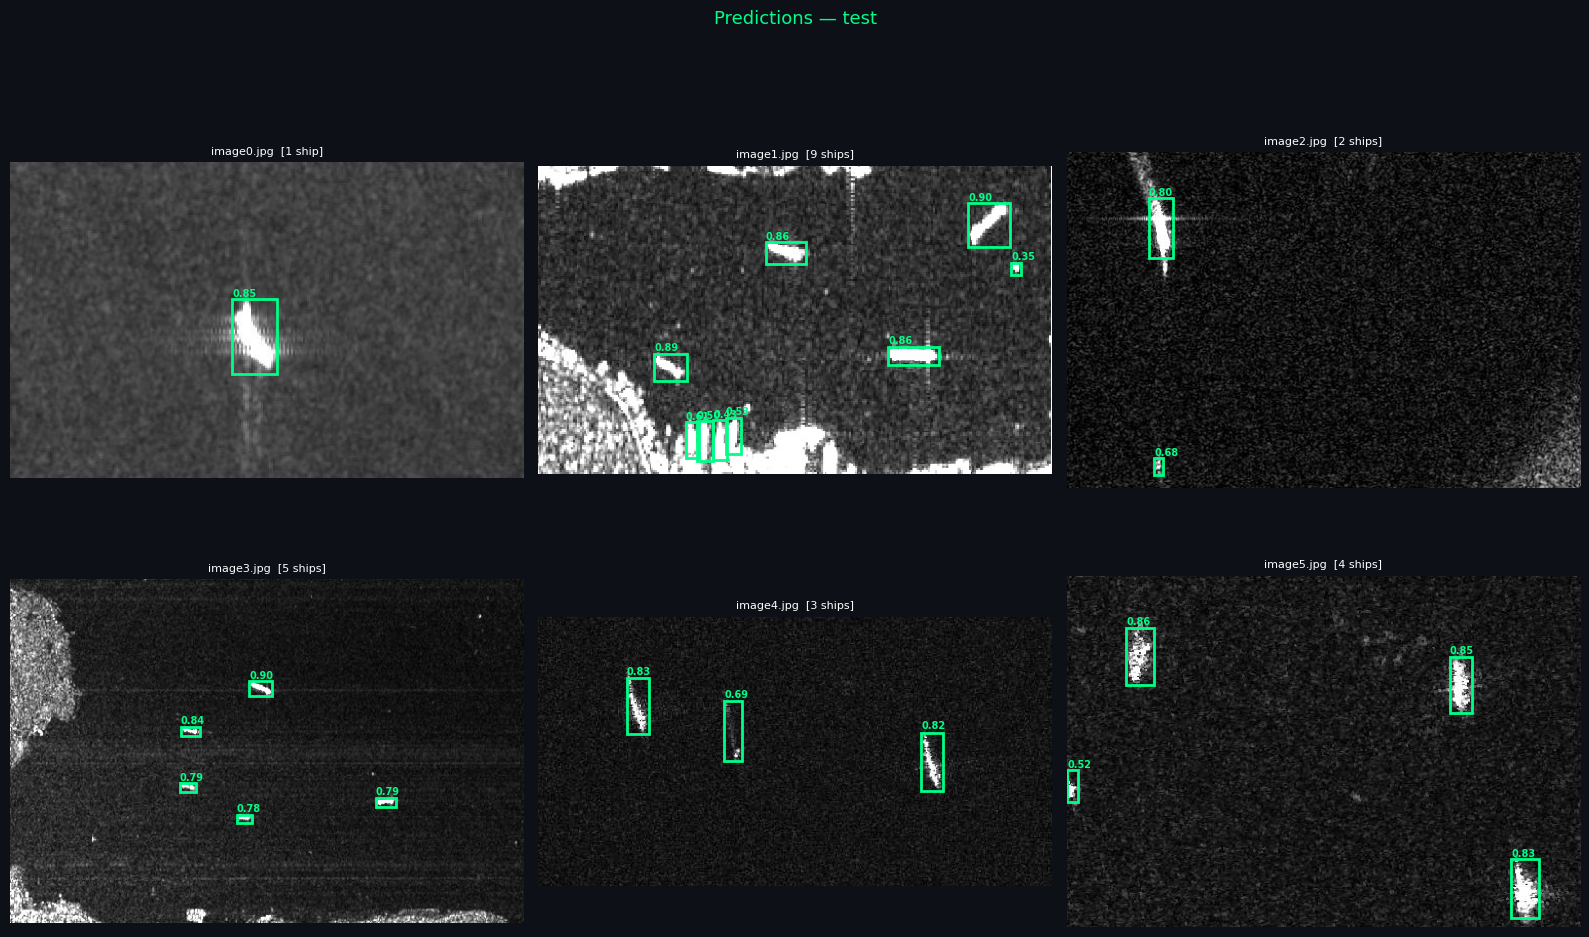

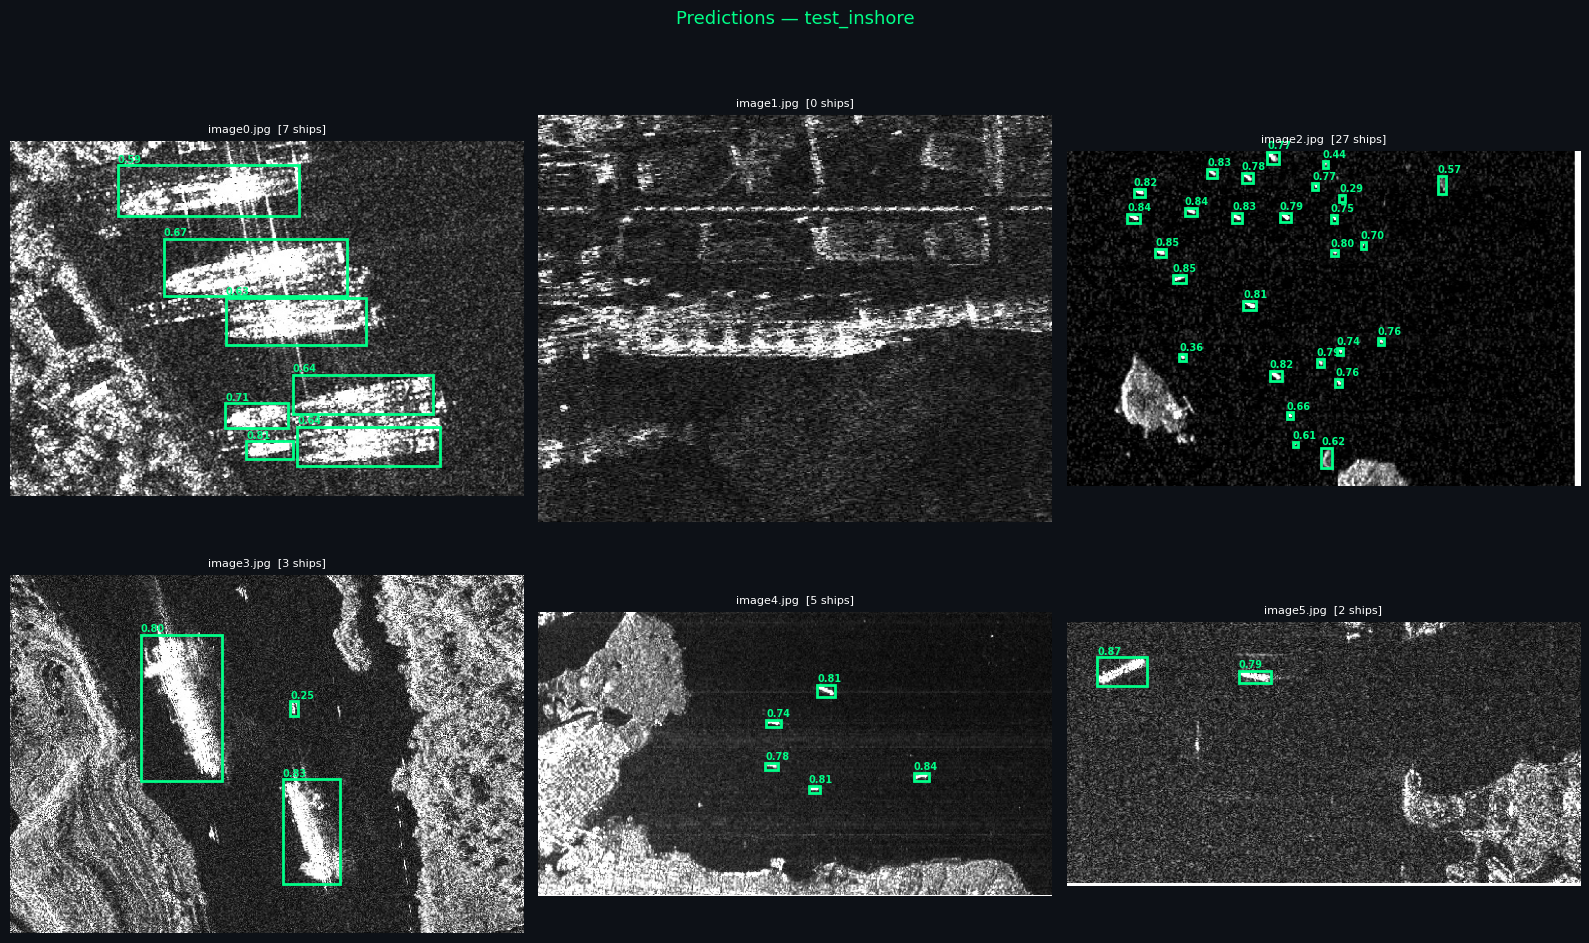

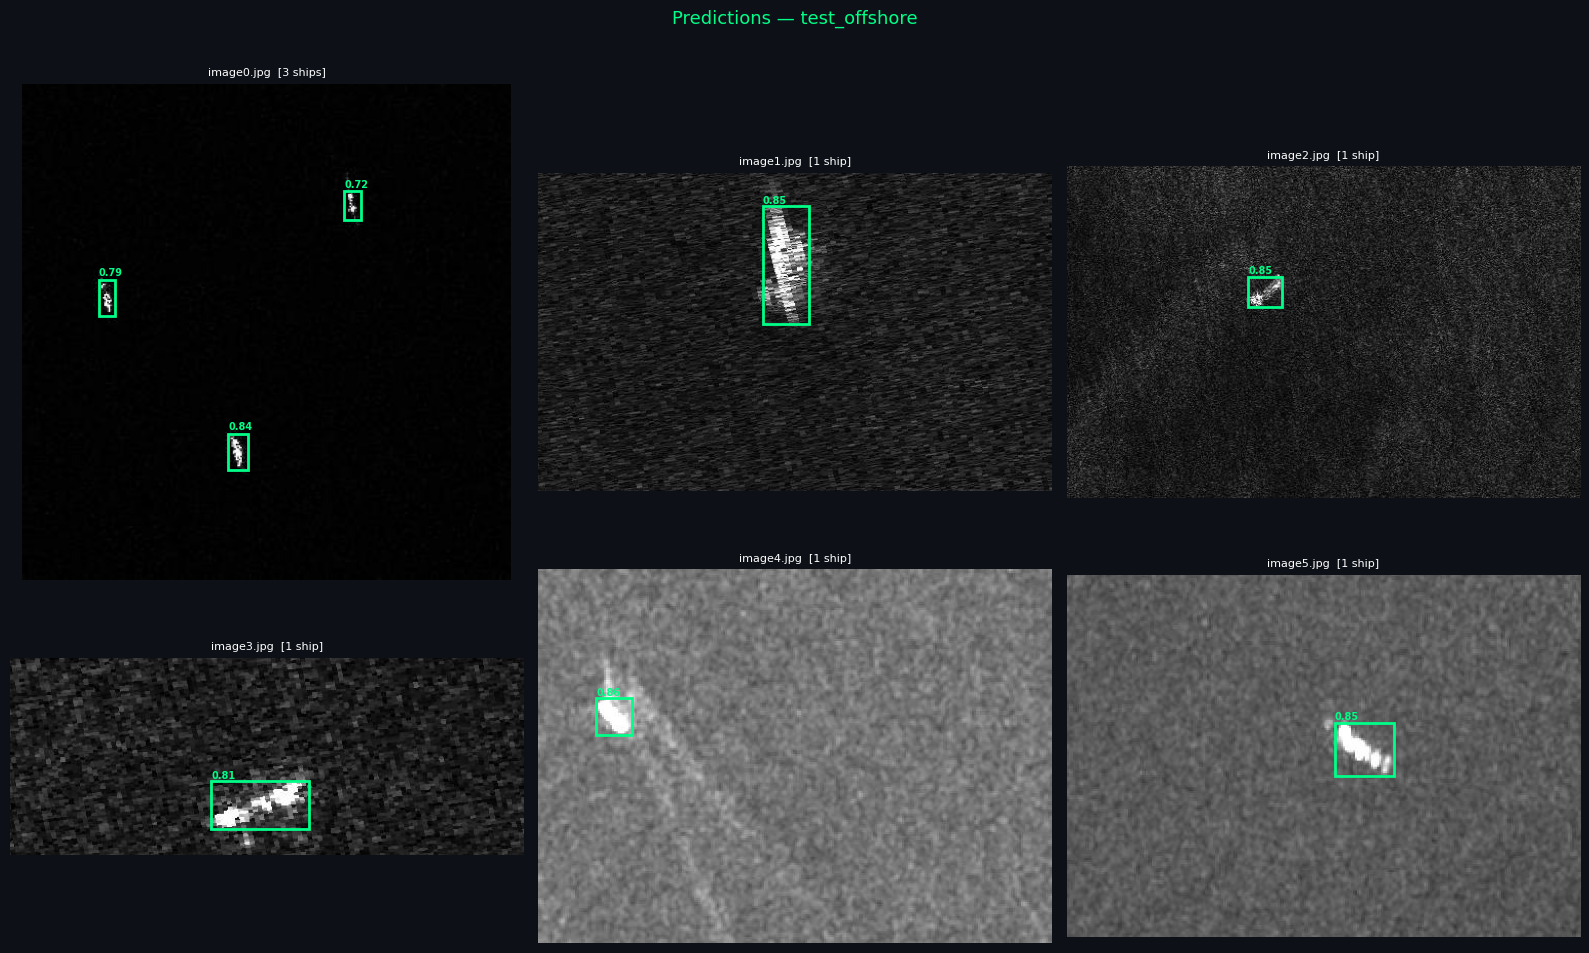

In [32]:
import glob
from pathlib import Path

def visualise_predictions(model, img_dir, split_name, n=6, conf=0.25):
    imgs = glob.glob(os.path.join(img_dir, "images", "*.*"))
    if not imgs:
        print(f"No images found in {img_dir}/images")
        return
    sample = random.sample(imgs, min(n, len(imgs)))

    preds = model.predict(source=sample, conf=conf, iou=0.45, verbose=False)

    cols = 3
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    fig.patch.set_facecolor('#0d1117')
    axes = np.array(axes).flatten()

    for ax, pred in zip(axes, preds):
        img_bgr = pred.orig_img
        img_rgb = img_bgr[:, :, ::-1]   # BGR → RGB
        ax.imshow(img_rgb)
        ax.set_facecolor('#0d1117')

        boxes = pred.boxes
        n_det = len(boxes)
        if n_det > 0:
            for box in boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf_val = box.conf[0].item()
                rect = patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1,
                    linewidth=2, edgecolor='#00ff88', facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 3, f"{conf_val:.2f}",
                        color='#00ff88', fontsize=7, fontweight='bold')

        fname = Path(pred.path).name
        ax.set_title(f"{fname}  [{n_det} ship{'s' if n_det!=1 else ''}]",
                     color='white', fontsize=8)
        ax.axis('off')

    for ax in axes[len(sample):]:
        ax.set_visible(False)

    plt.suptitle(f"Predictions — {split_name}", color='#00ff88', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


for split in test_splits:
    visualise_predictions(trained_model, split_dirs[split], split, n=6)

## 10. Precision-Recall Curve

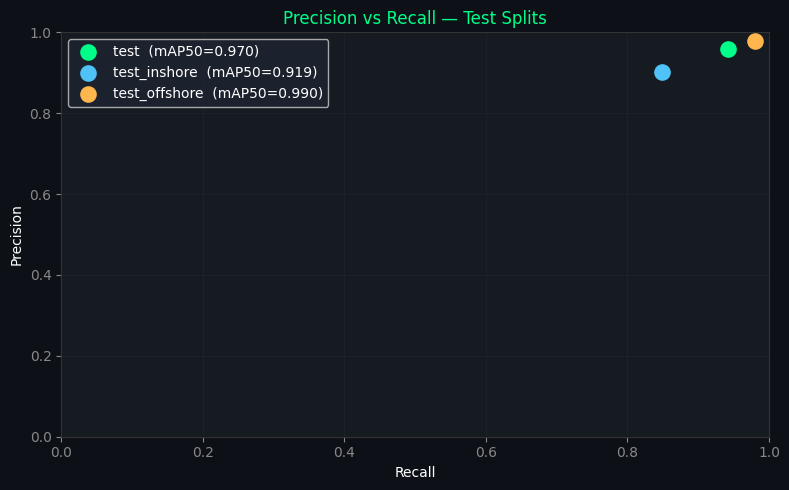

In [33]:
# The PR curve is saved automatically by YOLO during val
pr_png = "/content/runs/ssdd_yolov8n/val/P_curve.png"
if os.path.isfile(pr_png):
    from IPython.display import Image as IPImage, display
    display(IPImage(pr_png))
else:
    # Plot from eval_results
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')
    colors = ['#00ff88', '#4fc3f7', '#ffb74d']
    for (split, r), c in zip(eval_results.items(), colors):
        ax.scatter(r.box.mr, r.box.mp, label=f"{split}  (mAP50={r.box.map50:.3f})",
                   color=c, s=120, zorder=5)
    ax.set_xlabel('Recall',    color='white')
    ax.set_ylabel('Precision', color='white')
    ax.set_title('Precision vs Recall — Test Splits', color='#00ff88')
    ax.tick_params(colors='#888')
    ax.spines[:].set_color('#333')
    ax.grid(alpha=0.15, color='#444')
    ax.legend(facecolor='#1e2530', labelcolor='white')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()

## 11. Speed Benchmark

In [34]:
import time

test_imgs = glob.glob(os.path.join(split_dirs['test'], "images", "*.*"))[:20]

# Warm-up
_ = trained_model.predict(test_imgs[:2], verbose=False)

start = time.perf_counter()
_ = trained_model.predict(test_imgs, conf=0.25, verbose=False)
elapsed = time.perf_counter() - start

fps = len(test_imgs) / elapsed
ms  = elapsed / len(test_imgs) * 1000

print(f"Inference on {len(test_imgs)} images")
print(f"  Total   : {elapsed:.2f}s")
print(f"  FPS     : {fps:.1f}")
print(f"  ms/img  : {ms:.1f} ms")

Inference on 20 images
  Total   : 0.78s
  FPS     : 25.6
  ms/img  : 39.1 ms


## 12. Save Best Weights to Drive

In [35]:
SAVE_DIR = os.path.join(DRIVE_DATASET_PATH, "model_weights")
os.makedirs(SAVE_DIR, exist_ok=True)

dst = os.path.join(SAVE_DIR, "ssdd_yolov8n_best.pt")
shutil.copy2(BEST_WEIGHTS, dst)
print(f"✅ Weights saved to Google Drive: {dst}")

# Also zip the full run folder
shutil.make_archive(
    os.path.join(SAVE_DIR, "ssdd_run"),
    'zip',
    "/content/runs",
    "ssdd_yolov8n"
)
print(f"✅ Full run zipped to: {SAVE_DIR}/ssdd_run.zip")

✅ Weights saved to Google Drive: /content/drive/MyDrive/dataset/coco_style/model_weights/ssdd_yolov8n_best.pt
✅ Full run zipped to: /content/drive/MyDrive/dataset/coco_style/model_weights/ssdd_run.zip


## 13. (Optional) Export to ONNX for Deployment

In [ ]:
# Uncomment to export
# onnx_path = trained_model.export(format='onnx', imgsz=640, opset=12)
# shutil.copy2(onnx_path, os.path.join(SAVE_DIR, 'ssdd_yolov8n.onnx'))
# print("ONNX model saved to Drive.")
print("Uncomment the lines above to export ONNX.")

---
## Summary

| Step | Detail |
|------|--------|
| Model | YOLOv8n (nano, ~3.2M params) |
| Dataset | SSDD (COCO format) |
| Splits | train / test / test_inshore / test_offshore |
| Input size | 640×640 |
| Augmentations | Mosaic, flip, rotation (no HSV — SAR is grayscale) |
| Output | best.pt + full run zip saved to Google Drive |

**Next steps to improve mAP:**
- Increase `epochs` to 100–150  
- Try `yolov8s.pt` (small) for a ~+3 mAP boost  
- Add `scale=0.5` augmentation (ship scale variance in SAR)  
- Lower `conf` threshold to 0.1 for high-recall maritime surveillance  